# Training — Sistem Klasifikasi Sampah
## CC26-PSU384 | Coding Camp 2026 × DBS Foundation

**Dikerjakan oleh:** Naswa Resaptania Zhulvan (AI Engineer)  
**Berdasarkan kode:** Raffi Dewangga Susanto (AI Engineer)

Notebook ini menjalankan **full training pipeline** dari awal sampai model siap dipakai.  

| Bagian | Isi |
|--------|-----|
| 1 | Setup environment & GPU |
| 2 | Upload & ekstrak dataset |
| 3 | Konfigurasi global |
| 4 | Definisi model (kode Raffi) |
| 5 | Data pipeline |
| 6 | Training Phase 1 — frozen base |
| 7 | Training Phase 2 — fine-tuning |
| 8 | Evaluasi akhir & confusion matrix |
| 9 | Export model (.keras, SavedModel, TFLite) |
| 10 | Integrasi Claude AI (info edukatif) |
| 11 | REST API Flask |
| 12 | Download semua artefak |



## Bagian 1 — Setup Environment

In [ ]:
# Install library tambahan
!pip install -q anthropic scikit-learn seaborn matplotlib
print("Selesai")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 13.8 MB/s eta 0:00:00
Selesai


## Bagian 2 — Upload Dataset

In [ ]:
# Upload dari komputer
from google.colab import files
import zipfile, os

print("Pilih file")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

print(f"Mengekstrak {zip_name} ...")
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset')

os.remove(zip_name)
print("Selesai")


Pilih file


Saving dataset_final.zip to dataset_final.zip
Mengekstrak dataset_final.zip ...
Selesai


In [ ]:
# Verifikasi struktur dataset
import os

DATA_DIR = '/content/dataset'
expected = ['train', 'validation', 'test']
classes  = ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']

print(f"{'Split':12s}  {'Kelas':10s}  {'Gambar':>8s}")
print("-" * 36)
ok = True
for split in expected:
    for cls in classes:
        path = f'{DATA_DIR}/{split}/{cls}'
        if os.path.exists(path):
            n = len(os.listdir(path))
            print(f"{split:12s}  {cls:10s}  {n:>8d}")
        else:
            print(f"TIDAK ADA: {path}")
            ok = False
    print("-" * 36)

print("Dataset aman" if ok else "Ada kesalahan")


Split         Kelas         Gambar
------------------------------------
train         Kaca             513
train         Kardus           560
train         Kertas           630
train         Logam            636
train         Plastik          611
train         Residu           484
------------------------------------
validation    Kaca             109
validation    Kardus           120
validation    Kertas           135
validation    Logam            136
validation    Plastik          130
validation    Residu           103
------------------------------------
test          Kaca             111
test          Kardus           120
test          Kertas           135
test          Logam            137
test          Plastik          132
test          Residu           105
------------------------------------
Dataset aman


## Bagian 3 — Konfigurasi Global


In [7]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')

DATA_DIR      = '/content/dataset'
ARTIFACT_DIR  = '/content/artifacts'
MODEL_DIR     = f'{ARTIFACT_DIR}/model'
TFLITE_DIR    = f'{ARTIFACT_DIR}/tflite'
LOG_DIR       = f'{ARTIFACT_DIR}/logs'
EVAL_DIR      = f'{ARTIFACT_DIR}/evaluation'
CLASS_NAMES_PATH = f'{ARTIFACT_DIR}/class_names.txt'
KERAS_PATH    = f'{MODEL_DIR}/waste_classifier_phase1.keras'
KERAS_FINAL   = f'{MODEL_DIR}/waste_classifier_final.keras'
SAVED_MODEL   = f'{MODEL_DIR}/saved_model'
TFLITE_PATH   = f'{TFLITE_DIR}/waste_classifier.tflite'

for d in [MODEL_DIR, TFLITE_DIR, LOG_DIR, EVAL_DIR]:
    os.makedirs(d, exist_ok=True)

CLASS_NAMES = ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

# Frozen base
P1_EPOCHS   = 20       # epoch maksimum phase 1
P1_LR       = 1e-3     # learning rate phase 1
P1_PATIENCE = 6        # early stopping patience

# Fine tuning
P2_EPOCHS        = 20  # epoch maksimum phase 2
P2_LR            = 5e-5
P2_PATIENCE      = 6
UNFREEZE_LAYERS  = 40  # jumlah layer terakhir EfficientNetV2B0 yang di-unfreeze

# Target minimum
TARGET_ACC = 0.85

print("Berhasil")
print(f"  Kelas      : {CLASS_NAMES}")
print(f"  IMG_SIZE   : {IMG_SIZE}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  Target Acc : {TARGET_ACC*100:.0f}%")


Berhasil
  Kelas      : ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
  IMG_SIZE   : (224, 224)
  BATCH_SIZE : 32
  Target Acc : 85%


## Bagian 4 — Definisi Model


In [8]:
# ChannelAttention
import tensorflow as tf

class ChannelAttention(tf.keras.layers.Layer):
    """
    Squeeze-and-Excitation Block (Hu et al., 2018).
    Menggabungkan average-pool + max-pool untuk menghasilkan
    bobot attention per channel yang lebih akurat.
    """
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        hidden   = max(channels // self.ratio, 1)
        self.avg_pool      = tf.keras.layers.GlobalAveragePooling2D()
        self.max_pool      = tf.keras.layers.GlobalMaxPooling2D()
        self.shared_dense1 = tf.keras.layers.Dense(hidden, activation='relu')
        self.shared_dense2 = tf.keras.layers.Dense(channels)
        super().build(input_shape)

    def call(self, inputs):
        avg       = self.shared_dense2(self.shared_dense1(self.avg_pool(inputs)))
        max_val   = self.shared_dense2(self.shared_dense1(self.max_pool(inputs)))
        attention = tf.nn.sigmoid(avg + max_val)
        attention = tf.reshape(attention, [-1, 1, 1, tf.shape(inputs)[-1]])
        return inputs * attention

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'ratio': self.ratio})
        return cfg

print("ChannelAttention siap!")


ChannelAttention siap!


In [9]:
# Custom Loss: FocalLoss
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss (Lin et al., 2017).
    Memberikan bobot lebih besar pada contoh yang sulit dipelajari,
    membantu mengatasi ketidakseimbangan antar kelas sampah.
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce     = -y_true * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1.0 - y_pred, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg

CUSTOM_OBJECTS = {
    'ChannelAttention': ChannelAttention,
    'FocalLoss':        FocalLoss,
}
print("Siap")


Siap


In [ ]:
# Arsitektur Model: EfficientNetV2B0 + ChannelAttention
def build_waste_classifier(num_classes, image_size=(224, 224), train_base=False):
    """
    Transfer Learning: EfficientNetV2B0 (ImageNet) + ChannelAttention head.

    Args:
        train_base : False = frozen (Phase 1), True = fine-tune (Phase 2)
    """
    inputs = tf.keras.Input(shape=(*image_size, 3), name='image')

    # Augmentasi built-in (hanya aktif saat training=True)
    augment = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.12),
        tf.keras.layers.RandomContrast(0.1),
    ], name='augmentation')

    x = augment(inputs)
    x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=(*image_size, 3),
    )
    base.trainable = train_base

    x = base(x, training=False)               # training=False agar BN base tetap frozen
    x = ChannelAttention(name='channel_attention')(x)
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_pool')(x)
    x = tf.keras.layers.BatchNormalization(name='head_bn')(x)
    x = tf.keras.layers.Dropout(0.35, name='dropout')(x)
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_features')(x)
    x = tf.keras.layers.Dropout(0.25, name='classifier_dropout')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='class_output')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name='waste_classifier')


def unfreeze_top_layers(model, n_layers=40):
    """Unfreeze N layer terakhir base model untuk Phase 2 fine-tuning."""
    base = model.get_layer('efficientnetv2-b0')
    base.trainable = True
    for layer in base.layers[:-n_layers]:
        layer.trainable = False
    trainable = sum(1 for l in model.layers if l.trainable)
    print(f"Trainable layers: {trainable} / {len(model.layers)}")
    print(f"Top {n_layers} layer EfficientNetV2B0 di-unfreeze")
    return model


# Preview model
model_preview = build_waste_classifier(NUM_CLASSES, train_base=False)
trainable   = sum(np.prod(v.shape) for v in model_preview.trainable_variables)
untrainable = sum(np.prod(v.shape) for v in model_preview.non_trainable_variables)
print(f"Trainable params   : {trainable:,}")
print(f"Non-trainable params: {untrainable:,}")
del model_preview


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable params   : 743,078
Non-trainable params: 5,921,914


## Bagian 5 — Data Pipeline




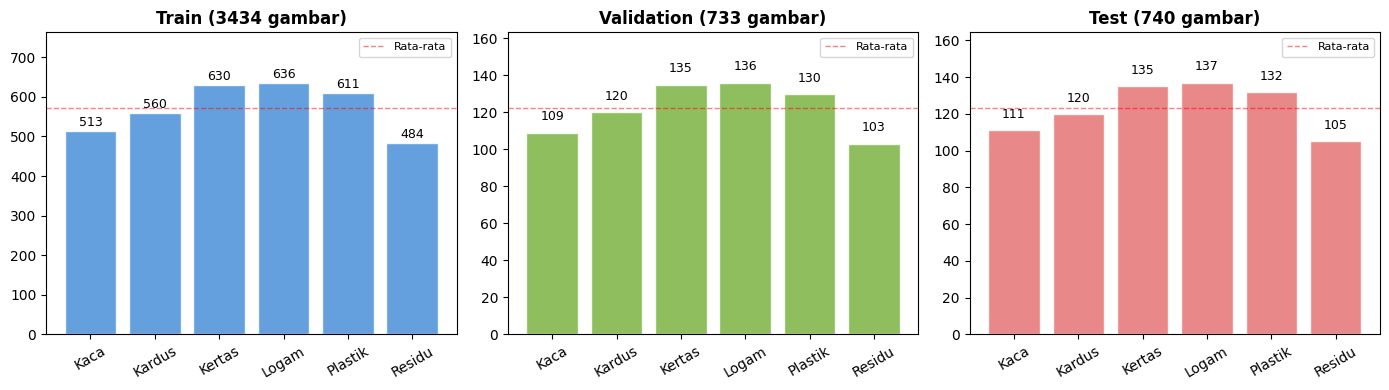

Tersimpan


In [ ]:
# Visualisasi distribusi kelas
import os, matplotlib.pyplot as plt

counts = {}
for split in ['train', 'validation', 'test']:
    counts[split] = {}
    for cls in CLASS_NAMES:
        path = f'{DATA_DIR}/{split}/{cls}'
        counts[split][cls] = len(os.listdir(path)) if os.path.exists(path) else 0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4A90D9', '#7CB342', '#E57373']
for ax, (split, color) in zip(axes, zip(['train', 'validation', 'test'], colors)):
    vals = [counts[split][c] for c in CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{split.capitalize()} ({sum(vals)} gambar)', fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(v), ha='center', va='bottom', fontsize=9)
    # Garis target balance
    ax.axhline(sum(vals)/NUM_CLASSES, color='red', linestyle='--',
               linewidth=1, alpha=0.5, label='Rata-rata')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/distribusi_kelas.png', dpi=130, bbox_inches='tight')
plt.show()
print("Tersimpan")


In [ ]:
# Load dataset & build pipeline
import tensorflow as tf

def load_split(directory, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels='inferred',
        label_mode='categorical',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
        class_names=CLASS_NAMES,    # paksa urutan kelas konsisten
    )

AUTOTUNE = tf.data.AUTOTUNE

# Load raw (masih ada class_names attribute)
raw_train = load_split(f'{DATA_DIR}/train',      shuffle=True)
raw_val   = load_split(f'{DATA_DIR}/validation', shuffle=False)
raw_test  = load_split(f'{DATA_DIR}/test',       shuffle=False)

# Simpan class_names sebelum di-map
actual_class_names = raw_train.class_names
with open(CLASS_NAMES_PATH, 'w') as f:
    f.write('\n'.join(actual_class_names))
print(f"Class names: {actual_class_names}")

# Preprocessing: normalisasi 0-1 (EfficientNetV2 punya preprocess sendiri di dalam model)
# Jadi di sini kita TIDAK normalisasi model yang handle via preprocess_input
def to_float(images, labels):
    return tf.cast(images, tf.float32), labels

train_ds = (raw_train
            .map(to_float, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(1000, seed=SEED)
            .prefetch(AUTOTUNE))

val_ds   = (raw_val
            .map(to_float, num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

test_ds  = (raw_test
            .map(to_float, num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")


Found 3434 files belonging to 6 classes.
Found 733 files belonging to 6 classes.
Found 740 files belonging to 6 classes.
Class names: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
Train batches : 108
Val batches   : 23
Test batches  : 24


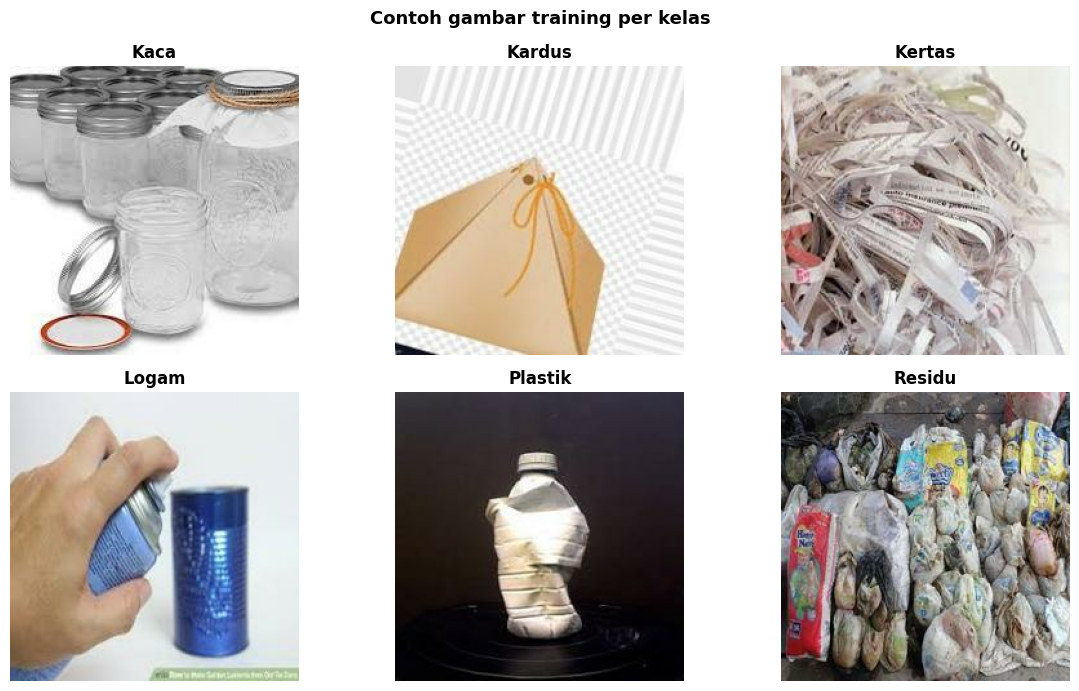

In [ ]:
# Visualisasi contoh gambar per kelas
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('Contoh gambar training per kelas', fontsize=13, fontweight='bold')

# Ambil satu batch
for images, labels in train_ds.take(1):
    seen = {}
    for img, lbl in zip(images.numpy(), labels.numpy()):
        cls_idx = int(np.argmax(lbl))
        cls_name = CLASS_NAMES[cls_idx]
        if cls_name not in seen:
            seen[cls_name] = img

for ax, cls in zip(axes.flatten(), CLASS_NAMES):
    if cls in seen:
        # Clip ke 0-255 untuk display
        disp = np.clip(seen[cls] / 255.0 if seen[cls].max() > 1 else seen[cls], 0, 1)
        ax.imshow(disp)
    ax.set_title(cls, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/contoh_gambar.png', dpi=120, bbox_inches='tight')
plt.show()


## Bagian 6 — Training Phase 1 (Base Frozen)

Base model (EfficientNetV2B0) di-**freeze** hanya head yang dilatih.  
Tujuan: biarkan custom head menyesuaikan diri dulu dengan fitur ImageNet.

Custom training loop menggunakan `tf.GradientTape`


In [ ]:
# Definisi training & validation step dengan GradientTape
import tensorflow as tf

# Buat metric baru tiap epoch
def make_metrics():
    return (
        tf.keras.metrics.Mean(name='train_loss'),
        tf.keras.metrics.CategoricalAccuracy(name='train_acc'),
        tf.keras.metrics.Mean(name='val_loss'),
        tf.keras.metrics.CategoricalAccuracy(name='val_acc'),
    )

@tf.function
def train_step(model, images, labels, loss_fn, optimizer,
               train_loss_m, train_acc_m):
    with tf.GradientTape() as tape:
        preds = model(images, training=True)
        loss  = loss_fn(labels, preds)
        if model.losses:
            loss = loss + tf.add_n(model.losses)
    grads = tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss_m.update_state(loss)
    train_acc_m.update_state(labels, preds)

@tf.function
def val_step(model, images, labels, loss_fn, val_loss_m, val_acc_m):
    preds = model(images, training=False)
    loss  = loss_fn(labels, preds)
    val_loss_m.update_state(loss)
    val_acc_m.update_state(labels, preds)

print("Training step siap!")

Training step siap!


In [ ]:
# Fungsi training loop lengkap
import time, datetime

def run_training(model, train_ds, val_ds, epochs, lr,
                 save_path, log_subdir, patience, phase_name):

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn   = FocalLoss(gamma=2.0, alpha=0.25)
    writer    = tf.summary.create_file_writer(f'{LOG_DIR}/{log_subdir}')

    best_val_acc = 0.0
    patience_cnt = 0
    history      = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'='*62}")
    print(f"  {phase_name}")
    print(f"  Epochs: {epochs} | LR: {lr} | Patience: {patience}")
    print(f"  Save  : {save_path}")
    print(f"{'='*62}")

    for epoch in range(1, epochs + 1):
        # Buat metric baru setiap epoch, hindari reset_states/reset_state
        train_loss_m, train_acc_m, val_loss_m, val_acc_m = make_metrics()

        t0 = time.time()

        for images, labels in train_ds:
            train_step(model, images, labels, loss_fn, optimizer,
                       train_loss_m, train_acc_m)

        for images, labels in val_ds:
            val_step(model, images, labels, loss_fn,
                     val_loss_m, val_acc_m)

        t_loss  = float(train_loss_m.result())
        t_acc   = float(train_acc_m.result())
        v_loss  = float(val_loss_m.result())
        v_acc   = float(val_acc_m.result())
        elapsed = time.time() - t0

        history['loss'].append(t_loss)
        history['acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        with writer.as_default():
            tf.summary.scalar(f'{phase_name}/loss/train',     t_loss, step=epoch)
            tf.summary.scalar(f'{phase_name}/loss/val',       v_loss, step=epoch)
            tf.summary.scalar(f'{phase_name}/accuracy/train', t_acc,  step=epoch)
            tf.summary.scalar(f'{phase_name}/accuracy/val',   v_acc,  step=epoch)
        writer.flush()

        bar  = '█' * int(v_acc * 30) + '░' * (30 - int(v_acc * 30))
        mark = ' <-- best' if v_acc > best_val_acc else ''
        print(f"Ep {epoch:3d}/{epochs} [{bar}] "
              f"loss:{t_loss:.4f} acc:{t_acc:.4f} | "
              f"val_loss:{v_loss:.4f} val_acc:{v_acc:.4f} "
              f"({elapsed:.0f}s){mark}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            model.save(save_path)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"\nEarly stopping di epoch {epoch}")
                break

    print(f"\nBest Val Acc: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    if best_val_acc >= TARGET_ACC:
        print(f"Target {TARGET_ACC*100:.0f}% TERCAPAI!")
    else:
        print(f"Belum target. Kurang {(TARGET_ACC - best_val_acc)*100:.2f}%")

    return history, best_val_acc

In [ ]:
# Phase 1
# Build model fresh dengan base frozen
model = build_waste_classifier(NUM_CLASSES, train_base=False)

# Training
history_p1, best_p1 = run_training(
    model     = model,
    train_ds  = train_ds,
    val_ds    = val_ds,
    epochs    = P1_EPOCHS,
    lr        = P1_LR,
    save_path = KERAS_PATH,
    log_subdir= f'phase1_{datetime.datetime.now().strftime("%H%M%S")}',
    patience  = P1_PATIENCE,
    phase_name= 'Phase1_FrozenBase',
)



  Phase1_FrozenBase
  Epochs: 20 | LR: 0.001 | Patience: 6
  Save  : /content/artifacts/model/waste_classifier_phase1.keras
Ep   1/20 [█████████████████████████░░░░░] loss:0.1677 acc:0.6881 | val_loss:0.0649 val_acc:0.8404 (35s) <-- best
Ep   2/20 [██████████████████████████░░░░] loss:0.0957 acc:0.7819 | val_loss:0.0445 val_acc:0.8759 (24s) <-- best
Ep   3/20 [██████████████████████████░░░░] loss:0.0753 acc:0.8142 | val_loss:0.0451 val_acc:0.8827 (23s) <-- best
Ep   4/20 [██████████████████████████░░░░] loss:0.0647 acc:0.8209 | val_loss:0.0404 val_acc:0.8950 (24s) <-- best
Ep   5/20 [██████████████████████████░░░░] loss:0.0561 acc:0.8366 | val_loss:0.0436 val_acc:0.8799 (26s)
Ep   6/20 [██████████████████████████░░░░] loss:0.0442 acc:0.8567 | val_loss:0.0428 val_acc:0.8881 (23s)
Ep   7/20 [██████████████████████████░░░░] loss:0.0456 acc:0.8626 | val_loss:0.0389 val_acc:0.8963 (24s) <-- best
Ep   8/20 [██████████████████████████░░░░] loss:0.0365 acc:0.8824 | val_loss:0.0423 val_acc:0.8

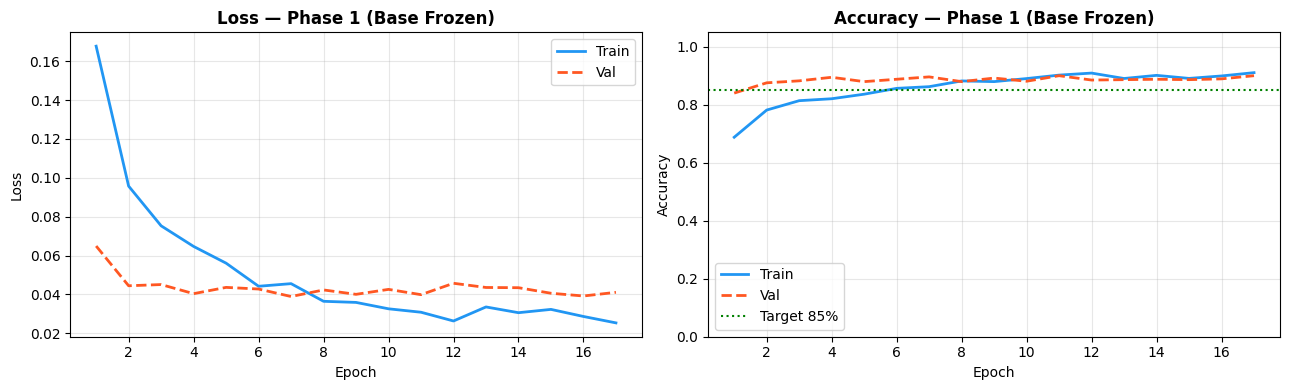

Kurva tersimpan: kurva_phase1.png


In [ ]:
# Plot kurva training Phase 1
def plot_history(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    eps = range(1, len(history['loss']) + 1)

    ax1.plot(eps, history['loss'],     label='Train',  color='#2196F3', lw=2)
    ax1.plot(eps, history['val_loss'], label='Val',    color='#FF5722', lw=2, ls='--')
    ax1.set_title(f'Loss — {title}', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(eps, history['acc'],     label='Train', color='#2196F3', lw=2)
    ax2.plot(eps, history['val_acc'], label='Val',   color='#FF5722', lw=2, ls='--')
    ax2.axhline(TARGET_ACC, color='green', ls=':', lw=1.5, label=f'Target {TARGET_ACC*100:.0f}%')
    ax2.set_title(f'Accuracy — {title}', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{EVAL_DIR}/{save_name}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Kurva tersimpan: {save_name}.png")

plot_history(history_p1, 'Phase 1 (Base Frozen)', 'kurva_phase1')


## Bagian 7 — Training Phase 2 (Fine-Tuning)

Load model terbaik dari Phase 1, lalu **unfreeze 40 layer terakhir** EfficientNetV2B0.  
Gunakan learning rate **sangat kecil** agar bobot ImageNet tidak rusak.


In [ ]:
# Load model Phase 1 & unfreeze top layers
model = tf.keras.models.load_model(KERAS_PATH, custom_objects=CUSTOM_OBJECTS)
print(f"Model Phase 1 dimuat dari: {KERAS_PATH}")
print(f"Val accuracy terbaik Phase 1: {best_p1:.4f}")

# Unfreeze top N layer base model
model = unfreeze_top_layers(model, n_layers=UNFREEZE_LAYERS)

# Ringkasan parameter
trainable   = sum(np.prod(v.shape) for v in model.trainable_variables)
untrainable = sum(np.prod(v.shape) for v in model.non_trainable_variables)
print(f"Trainable params    : {trainable:,}")
print(f"Nontrainable params: {untrainable:,}")


Model Phase 1 dimuat dari: /content/artifacts/model/waste_classifier_phase1.keras
Val accuracy terbaik Phase 1: 0.9004
Trainable layers: 10 / 10
Top 40 layer EfficientNetV2B0 di-unfreeze
Trainable params    : 2,463,798
Nontrainable params: 4,201,194


In [ ]:
import tensorflow as tf, time, datetime

optimizer_p2 = tf.keras.optimizers.Adam(learning_rate=P2_LR)
loss_fn_p2   = FocalLoss(gamma=2.0, alpha=0.25)

dummy = tf.zeros((1, *IMG_SIZE, 3))
with tf.GradientTape() as tape:
    out  = model(dummy, training=True)
    loss = tf.reduce_mean(out)
grads = tape.gradient(loss, model.trainable_variables)
optimizer_p2.apply_gradients(zip(grads, model.trainable_variables))
print(f"Optimizer di-build ulang untuk {len(model.trainable_variables)} variabel trainable")

def train_step_p2(images, labels, train_loss_m, train_acc_m):
    with tf.GradientTape() as tape:
        preds = model(images, training=True)
        loss  = loss_fn_p2(labels, preds)
        if model.losses:
            loss = loss + tf.add_n(model.losses)
    grads = tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
    optimizer_p2.apply_gradients(zip(grads, model.trainable_variables))
    train_loss_m.update_state(loss)
    train_acc_m.update_state(labels, preds)

def val_step_p2(images, labels, val_loss_m, val_acc_m):
    preds = model(images, training=False)
    loss  = loss_fn_p2(labels, preds)
    val_loss_m.update_state(loss)
    val_acc_m.update_state(labels, preds)

print("Siap")

Optimizer di-build ulang untuk 46 variabel trainable
Siap


In [ ]:
writer       = tf.summary.create_file_writer(
    f'{LOG_DIR}/phase2_{datetime.datetime.now().strftime("%H%M%S")}'
)
best_p2      = 0.0
patience_cnt = 0
history_p2   = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

print(f"\n{'='*62}")
print(f"  Phase2_FineTune")
print(f"  Epochs: {P2_EPOCHS} | LR: {P2_LR} | Patience: {P2_PATIENCE}")
print(f"  Save  : {KERAS_FINAL}")
print(f"{'='*62}")

for epoch in range(1, P2_EPOCHS + 1):
    train_loss_m, train_acc_m, val_loss_m, val_acc_m = make_metrics()
    t0 = time.time()

    for images, labels in train_ds:
        train_step_p2(images, labels, train_loss_m, train_acc_m)

    for images, labels in val_ds:
        val_step_p2(images, labels, val_loss_m, val_acc_m)

    t_loss  = float(train_loss_m.result())
    t_acc   = float(train_acc_m.result())
    v_loss  = float(val_loss_m.result())
    v_acc   = float(val_acc_m.result())
    elapsed = time.time() - t0

    history_p2['loss'].append(t_loss)
    history_p2['acc'].append(t_acc)
    history_p2['val_loss'].append(v_loss)
    history_p2['val_acc'].append(v_acc)

    with writer.as_default():
        tf.summary.scalar('Phase2/loss/train',     t_loss, step=epoch)
        tf.summary.scalar('Phase2/loss/val',       v_loss, step=epoch)
        tf.summary.scalar('Phase2/accuracy/train', t_acc,  step=epoch)
        tf.summary.scalar('Phase2/accuracy/val',   v_acc,  step=epoch)
    writer.flush()

    bar  = '█' * int(v_acc * 30) + '░' * (30 - int(v_acc * 30))
    mark = ' <-- best' if v_acc > best_p2 else ''
    print(f"Ep {epoch:3d}/{P2_EPOCHS} [{bar}] "
          f"loss:{t_loss:.4f} acc:{t_acc:.4f} | "
          f"val_loss:{v_loss:.4f} val_acc:{v_acc:.4f} "
          f"({elapsed:.0f}s){mark}")

    if v_acc > best_p2:
        best_p2 = v_acc
        model.save(KERAS_FINAL)
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= P2_PATIENCE:
            print(f"\nEarly stopping di epoch {epoch}")
            break

print(f"\nBest Val Acc Phase 2: {best_p2:.4f} ({best_p2*100:.2f}%)")
print(f"Best Val Acc Phase 1: {best_p1:.4f} ({best_p1*100:.2f}%)")
print(f"Target              : {TARGET_ACC:.4f} ({TARGET_ACC*100:.0f}%)")

if best_p2 >= TARGET_ACC:
    print("Target TERCAPAI! Lanjut ke Bagian 8 (evaluasi).")
else:
    print(f"Belum target, kurang {(TARGET_ACC - best_p2)*100:.2f}%.")


  Phase2_FineTune
  Epochs: 20 | LR: 5e-05 | Patience: 6
  Save  : /content/artifacts/model/waste_classifier_final.keras
Ep   1/20 [██████████████████████████░░░░] loss:0.0361 acc:0.8902 | val_loss:0.0399 val_acc:0.8772 (151s) <-- best
Ep   2/20 [██████████████████████████░░░░] loss:0.0306 acc:0.9033 | val_loss:0.0382 val_acc:0.8868 (131s) <-- best
Ep   3/20 [██████████████████████████░░░░] loss:0.0273 acc:0.9083 | val_loss:0.0367 val_acc:0.8963 (131s) <-- best
Ep   4/20 [██████████████████████████░░░░] loss:0.0224 acc:0.9222 | val_loss:0.0368 val_acc:0.8868 (132s)
Ep   5/20 [██████████████████████████░░░░] loss:0.0198 acc:0.9313 | val_loss:0.0353 val_acc:0.8936 (133s)
Ep   6/20 [██████████████████████████░░░░] loss:0.0201 acc:0.9327 | val_loss:0.0362 val_acc:0.8950 (132s)
Ep   7/20 [███████████████████████████░░░] loss:0.0185 acc:0.9354 | val_loss:0.0365 val_acc:0.9018 (130s) <-- best
Ep   8/20 [███████████████████████████░░░] loss:0.0185 acc:0.9292 | val_loss:0.0357 val_acc:0.9018 (

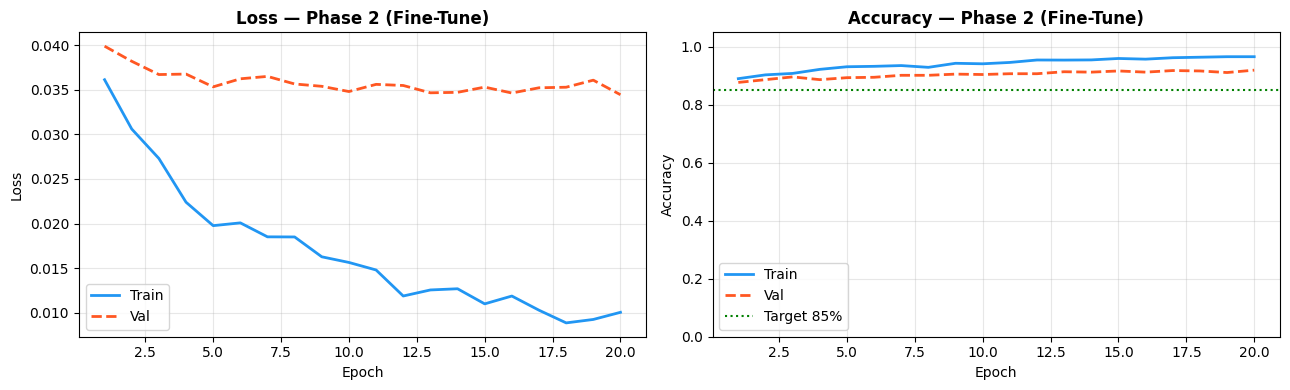

Kurva tersimpan: kurva_phase2.png


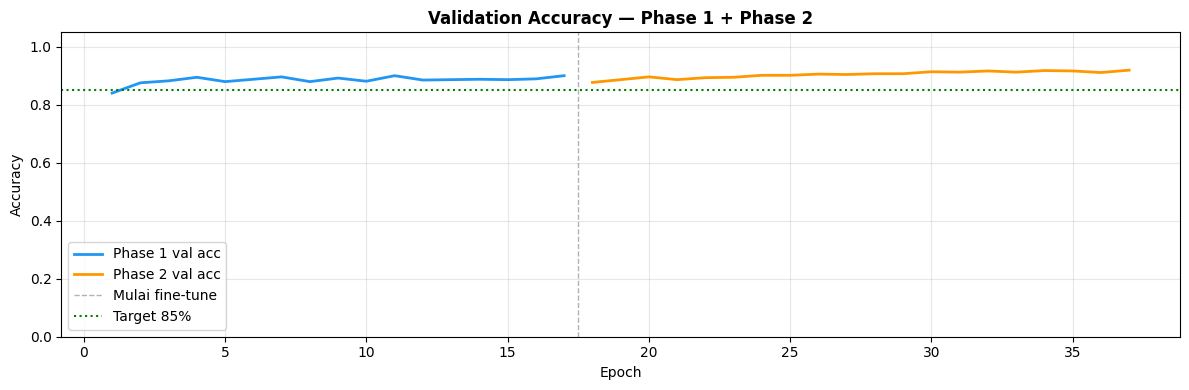

In [ ]:
# Plot kurva Phase 2 & perbandingan gabungan
plot_history(history_p2, 'Phase 2 (Fine-Tune)', 'kurva_phase2')

# Kurva gabungan
fig, ax = plt.subplots(figsize=(12, 4))
ep1 = list(range(1, len(history_p1['val_acc']) + 1))
ep2 = list(range(len(ep1) + 1, len(ep1) + len(history_p2['val_acc']) + 1))

ax.plot(ep1, history_p1['val_acc'], color='#2196F3', lw=2, label='Phase 1 val acc')
ax.plot(ep2, history_p2['val_acc'], color='#FF9800', lw=2, label='Phase 2 val acc')
ax.axvline(len(ep1) + 0.5, color='gray', ls='--', lw=1, alpha=0.6, label='Mulai fine-tune')
ax.axhline(TARGET_ACC, color='green', ls=':', lw=1.5, label=f'Target {TARGET_ACC*100:.0f}%')
ax.set_title('Validation Accuracy — Phase 1 + Phase 2', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/kurva_gabungan.png', dpi=130, bbox_inches='tight')
plt.show()


## Bagian 8 — Evaluasi Akhir pada Test Set


In [6]:
# Load model final & evaluasi test set
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load model terbaik
final_model = tf.keras.models.load_model(KERAS_FINAL, custom_objects=CUSTOM_OBJECTS)
print(f"Model dimuat: {KERAS_FINAL}")

# Kumpulkan prediksi
y_true, y_pred, y_prob = [], [], []

print("Mengevaluasi test set ...")
for images, labels in test_ds:
    probs = final_model(images, training=False).numpy()
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Metrik utama
accuracy = np.mean(y_true == y_pred)
mae = np.mean(np.abs(np.eye(NUM_CLASSES)[y_true] - y_prob))

print(f"\n{'='*50}")
print(f"  TEST ACCURACY : {accuracy*100:.2f}%  {'OK' if accuracy >= TARGET_ACC else 'BELUM TARGET'}")
print(f"  TEST MAE      : {mae:.4f}       {'OK' if mae <= 0.02 else 'di atas 0.02'}")
print(f"{'='*50}")


NameError: name 'tf' is not defined

In [ ]:
# Classification Report per kelas
print("\nClassification Report")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))



Classification Report
              precision    recall  f1-score   support

        Kaca     0.9391    0.9730    0.9558       111
      Kardus     0.9655    0.9333    0.9492       120
      Kertas     0.9231    0.8889    0.9057       135
       Logam     0.8955    0.8759    0.8856       137
     Plastik     0.8571    0.8636    0.8604       132
      Residu     0.8571    0.9143    0.8848       105

    accuracy                         0.9054       740
   macro avg     0.9063    0.9082    0.9069       740
weighted avg     0.9061    0.9054    0.9055       740



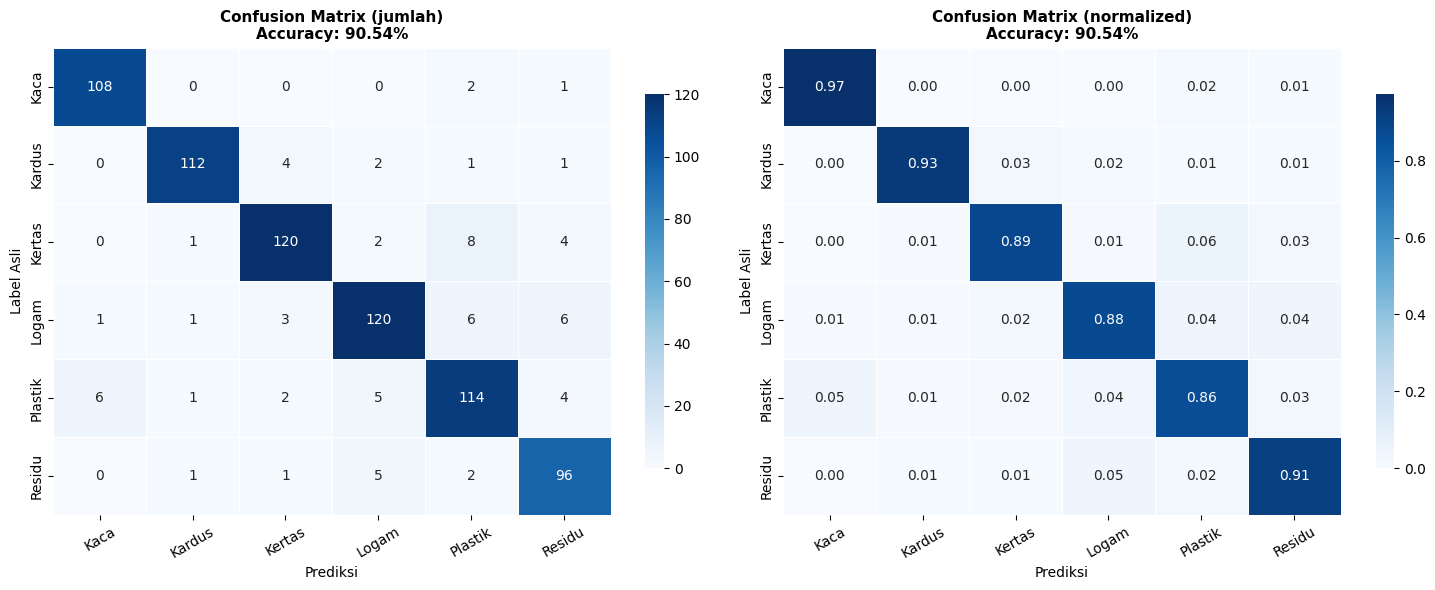

Confusion matrix tersimpan!


In [ ]:
# Confusion Matrix (jumlah & normalized)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (jumlah)', 'Confusion Matrix (normalized)']
):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{title}\nAccuracy: {accuracy*100:.2f}%', fontsize=11, fontweight='bold')
    ax.set_ylabel('Label Asli'); ax.set_xlabel('Prediksi')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix tersimpan!")


In [ ]:
# Analisis kelas paling sulit
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("Akurasi per kelas:")
print("-" * 35)
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar  = '█' * int(acc * 20)
    flag = '  <-- perlu perhatian' if acc < 0.80 else ''
    print(f"  {cls:8s}: {acc*100:5.1f}%  {bar}{flag}")
print("-" * 35)

worst_idx  = int(np.argmin(per_class_acc))
best_idx   = int(np.argmax(per_class_acc))
print(f"\nKelas tersulit : {CLASS_NAMES[worst_idx]} ({per_class_acc[worst_idx]*100:.1f}%)")
print(f"Kelas terbaik  : {CLASS_NAMES[best_idx]}  ({per_class_acc[best_idx]*100:.1f}%)")


Akurasi per kelas:
-----------------------------------
  Kaca    :  97.3%  ███████████████████
  Kardus  :  93.3%  ██████████████████
  Kertas  :  88.9%  █████████████████
  Logam   :  87.6%  █████████████████
  Plastik :  86.4%  █████████████████
  Residu  :  91.4%  ██████████████████
-----------------------------------

Kelas tersulit : Plastik (86.4%)
Kelas terbaik  : Kaca  (97.3%)


## Bagian 9 — Export Model

Export ke tiga format: `.keras` (sudah ada dari training), `SavedModel` (untuk server),
dan `TFLite` (untuk mobile/Full Stack).


In [ ]:
# Export TFLite tanpa augmentation layer
import tensorflow as tf, os, numpy as np

os.makedirs(TFLITE_DIR, exist_ok=True)

# Buat model inference-only (tanpa augmentasi)
# Ambil layer setelah augmentasi dari model yang sudah ditraining
def build_inference_model(trained_model):
    """
    Buat model baru yang identik dengan trained_model
    tapi tanpa layer augmentasi di dalamnya.
    Layer augmentasi hanya dipakai saat training, bukan inference.
    """
    # Input baru
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name='image')

    # Skip layer augmentasi langsung ke EfficientNetV2B0
    x = inputs
    base_model = trained_model.get_layer('efficientnetv2-b0')

    # Preprocessing EfficientNetV2 (normalisasi pixel)
    x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

    # Pass melalui base model (tanpa augmentasi)
    x = base_model(x, training=False)

    # Lanjutkan head layers
    for layer in trained_model.layers:
        if layer.name in ['channel_attention', 'global_pool',
                          'head_bn', 'dropout', 'dense_features',
                          'classifier_dropout', 'class_output']:
            x = layer(x)

    inference_model = tf.keras.Model(inputs=inputs, outputs=x,
                                     name='waste_classifier_inference')
    return inference_model


inference_model = build_inference_model(final_model)
print("Inference model siap!")
print(f"Input  : {inference_model.input_shape}")
print(f"Output : {inference_model.output_shape}")

# Verifikasi output sama dengan model asli
dummy = tf.zeros((1, *IMG_SIZE, 3))
out_original  = final_model(dummy, training=False).numpy()
out_inference = inference_model(dummy, training=False).numpy()
print(f"\nSelisih output max: {np.max(np.abs(out_original - out_inference)):.6f}") # (Harus sangat kecil, < 0.001)

Inference model siap!
Input  : (None, 224, 224, 3)
Output : (None, 6)

Selisih output max: 0.000000


In [ ]:
# Konversi inference model ke TFLite
# Simpan inference model ke SavedModel dulu
INFERENCE_SAVED = f'{MODEL_DIR}/waste_classifier_inference_savedmodel'
inference_model.export(INFERENCE_SAVED)
print(f"Tersimpan!")

# Convert ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(INFERENCE_SAVED)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_bytes)

# Cek ukuran
size_mb = os.path.getsize(TFLITE_PATH) / 1024 / 1024
print(f"TFLite tersimpan: {TFLITE_PATH}")
print(f"Ukuran           : {size_mb:.1f} MB")

Saved artifact at '/content/artifacts/model/waste_classifier_inference_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132896908376400: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132896908367760: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132896908368720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908373712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908373328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908361808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908366416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908366992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908362768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132896908369680: TensorSpec

In [ ]:
# Test TFLite inference
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input  : {input_details[0]['shape']}  dtype={input_details[0]['dtype']}")
print(f"Output : {output_details[0]['shape']} dtype={output_details[0]['dtype']}")

# Test dengan gambar dummy
dummy_input = np.zeros((1, *IMG_SIZE, 3), dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], dummy_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

print(f"\nOutput probabilities: {output[0]}")
print(f"Sum (harus ~1.0)    : {output[0].sum():.4f}")
print(f"Predicted class     : {CLASS_NAMES[np.argmax(output[0])]}")
print("\nTFLite berjalan dengan baik.")

Input  : [  1 224 224   3]  dtype=<class 'numpy.float32'>
Output : [1 6] dtype=<class 'numpy.float32'>

Output probabilities: [0.02229298 0.55719227 0.01364257 0.0017405  0.13102381 0.2741079 ]
Sum (harus ~1.0)    : 1.0000
Predicted class     : Kardus

TFLite berjalan dengan baik.


## Bagian 10 — Download Semua Artefak


In [ ]:
# Download artefak (model + evaluasi + logs)
import shutil
from google.colab import files

# Zip semua artefak
shutil.make_archive('/content/artifacts_CC26PSU384', 'zip', '/content/artifacts')
print("Mengunduh artifacts_CC26PSU384.zip ...")
files.download('/content/artifacts_CC26PSU384.zip')


Mengunduh artifacts_CC26PSU384.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Ringkasan final untuk tim lainnya
print("=" * 58)
print("  RINGKASAN FINAL — Tim AI CC26-PSU384")
print("=" * 58)
print(f"  Phase 1 best val acc : {best_p1*100:.2f}%")
print(f"  Phase 2 best val acc : {best_p2*100:.2f}%")
print(f"  Test accuracy        : {accuracy*100:.2f}%   (target >= 85%)")
print(f"  Test MAE             : {mae:.4f}  (target <= 0.02)")
print()
print("  Model tersimpan:")
print(f"    {KERAS_FINAL}")
print(f"    {SAVED_MODEL}")
print(f"    {TFLITE_PATH}")
print()
print("  Evaluasi tersimpan:")
print(f"    {EVAL_DIR}/confusion_matrix_final.png")
print(f"    {EVAL_DIR}/kurva_phase1.png")
print(f"    {EVAL_DIR}/kurva_phase2.png")
print()
print("  Yang diberikan ke Full Stack:")
print(f"    - URL API ngrok (lihat Bagian 11)")
print(f"    - waste_classifier.tflite")
print(f"    - class_names.txt")
print("=" * 58)

if accuracy >= TARGET_ACC:
    print("\n  Model siap.")
else:
    print(f"\n  Akurasi {accuracy*100:.2f}%,masih perlu peningkatan.")


  RINGKASAN FINAL — Tim AI CC26-PSU384
  Phase 1 best val acc : 90.04%
  Phase 2 best val acc : 91.95%
  Test accuracy        : 90.54%   (target >= 85%)
  Test MAE             : 0.0515  (target <= 0.02)

  Model tersimpan:
    /content/artifacts/model/waste_classifier_final.keras
    /content/artifacts/model/saved_model
    /content/artifacts/tflite/waste_classifier.tflite

  Evaluasi tersimpan:
    /content/artifacts/evaluation/confusion_matrix_final.png
    /content/artifacts/evaluation/kurva_phase1.png
    /content/artifacts/evaluation/kurva_phase2.png

  Yang diberikan ke Full Stack:
    - URL API ngrok (lihat Bagian 11)
    - waste_classifier.tflite
    - class_names.txt

  Model siap.
